# **Sesión 1 - El modelo VAR**
## _Representación, estimación y pronóstico, a mano_

Este notebook construye todo **a mano**, para que ninguna pieza sea una caja negra. Trabajamos con un
VAR(2) bivariado en el crecimiento interanual de los precios de exportación ($x_t$) y de los ingresos
fiscales del gobierno central ($r_t$), con datos trimestrales del BCRP de 2002Q2 a 2017Q4.

1. Armar las matrices $Y$ y $X$ de la forma compacta.
2. Estimar por mínimos cuadrados (OLS) y verificar que coincide con máxima verosimilitud.
3. Armar la forma companion y verificar la estabilidad.
4. Pronosticar ocho trimestres y construir la banda con el ECM acumulado.

La notación sigue las diapositivas: $\Phi_\ell$ son las matrices de rezagos, $B$ ($k \times n$) apila
los coeficientes con la constante en la **primera** fila. El código está en inglés; el texto y las
etiquetas, en castellano.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import minimize

from MacroPy.plots_kalman import set_bse_style
import sys; sys.path.append("..")          # course_data.py vive en la raíz del repositorio
from course_data import load, macrofiscal, quarter, vintage

set_bse_style()

# Cargamos los datos
# ================================================================
levels = load()                               # copia congelada de la base del curso
data = macrofiscal(levels).loc[:"2017-12-01", ["x", "r"]]

span = f"{quarter(data.index[0])} a {quarter(data.index[-1])}"
print(f"Base del curso, descargada el {vintage()}")
print(f"Muestra: {span} ({len(data)} trimestres)")
data.describe().round(2)

Base del curso, descargada el 2026-10-03
Muestra: 2002Q2 a 2017Q4 (63 trimestres)


,x,r
count,63.00,63.00
mean,9.04,6.70
std,17.93,10.83
min,-29.33,-18.64
25%,-6.28,0.36
50%,11.10,7.64
75%,23.13,13.19
max,45.46,30.35


## 1. La forma compacta

Con dos variables y dos rezagos, cada fila de $X$ es $[\,1,\ x_{t-1},\ r_{t-1},\ x_{t-2},\ r_{t-2}\,]$
y cada fila de $Y$ es $[\,x_t,\ r_t\,]$. Las dos primeras observaciones se pierden: son la condición
inicial. La constante va en la primera fila de $B$; `MacroPy` la pone al final, así que antes de
comparar hay que reordenar.

In [2]:
n, p = 2, 2                                  # variables and lags
y = data.to_numpy()
T = len(y) - p
Y = y[p:]                                    # T x n
X = np.column_stack([np.ones(T), y[p - 1:-1], y[p - 2:-2]])
k = X.shape[1]                               # k = n p + 1
rows = ["constante", "x(-1)", "r(-1)", "x(-2)", "r(-2)"]

print(f"Y: {Y.shape}   X: {X.shape}   B: {(k, n)}")
pd.DataFrame(X[:4], columns=rows, index=data.index[p:p + 4]).round(2)

Y: (61, 2)   X: (61, 5)   B: (5, 2)


,constante,x(-1),r(-1),x(-2),r(-2)
date,,,,,
2002-12-01,1.0,6.93,14.79,5.91,7.94
2003-03-01,1.0,11.11,9.87,6.93,14.79
2003-06-01,1.0,11.10,17.57,11.11,9.87
2003-09-01,1.0,4.12,6.13,11.10,17.57


## 2. Mínimos cuadrados y máxima verosimilitud

$\hat B = (X'X)^{-1}X'Y$. Con errores gaussianos, la log-verosimilitud es
$\ell(B,\Sigma) = -\tfrac{T}{2}\log|\Sigma| - \tfrac12\operatorname{tr}[\Sigma^{-1}(Y-XB)'(Y-XB)]$.
Concentrando $\Sigma = U'U/T$, maximizar $\ell$ equivale a minimizar $\log|U'U/T|$. Lo verificamos
con un optimizador numérico que parte de $B = 0$ y no sabe nada de MCO.

In [3]:
# OLS usando álgebra matricial
# ================================================================
B_ols = np.linalg.solve(X.T @ X, X.T @ Y)
U = Y - X @ B_ols

# Estimación por Máxima Verosimilitud
# ================================================================
def neg_loglik(b):
    """Concentrated log-likelihood (negative), Sigma = U'U / T."""
    E = Y - X @ b.reshape(k, n)
    return 0.5 * T * np.linalg.slogdet(E.T @ E / T)[1]

res = minimize(neg_loglik, np.zeros(k * n), method="BFGS",
               options={"gtol": 1e-8, "maxiter": 5000})
B_ml = res.x.reshape(k, n)

print(f"max |B_MV - B_MCO| = {np.abs(B_ml - B_ols).max():.1e}")
print("log-verosimilitud concentrada: "
      f"en MCO {-neg_loglik(B_ols.ravel()):.6f} | "
      f"en el óptimo numérico {-res.fun:.6f}")
columns = ["ecuación de x", "ecuación de r"]
pd.DataFrame(B_ols, index=rows, columns=columns).round(3)

max |B_MV - B_MCO| = 1.1e-06
log-verosimilitud concentrada: en MCO -226.449117 | en el óptimo numérico -226.449117


,ecuación de x,ecuación de r
constante,2.025,1.199
x(-1),1.316,0.427
r(-1),-0.067,0.464
x(-2),-0.518,-0.179
r(-2),0.049,0.004


Las dos rutas llegan al mismo $\hat B$. La diferencia está en lo que cada una permite hacer después:
la verosimilitud es una **función** de los parámetros, no solo un punto, y es exactamente el objeto
que el enfoque bayesiano multiplica por el prior.

## 3. La forma companion y la estabilidad

Todo VAR($p$) es un VAR(1) de mayor dimensión. Con $p = 2$, $\tilde{\mathbf y}_t = (\mathbf y_t', \mathbf y_{t-1}')'$
y la matriz $F$ apila $[\Phi_1\ \Phi_2]$ sobre $[I\ 0]$. El sistema es estable si todos los autovalores
de $F$ están dentro del círculo unitario, y entonces existe la media incondicional
$\mu = (I_n - \Phi_1 - \Phi_2)^{-1} c$.

In [4]:
# B tiene la constante en la primera fila y luego los rezagos: x(-1), r(-1), x(-2), r(-2).
c = B_ols[0]
Phi1, Phi2 = B_ols[1:3].T, B_ols[3:5].T       # fila i: ecuación i; columna j: variable j rezagada

F = np.block([[Phi1, Phi2],
              [np.eye(n), np.zeros((n, n))]])
c_tilde = np.r_[c, np.zeros(n)]
J = np.hstack([np.eye(n), np.zeros((n, n))])    # selector: y_t = J ỹ_t

modulos = np.sort(np.abs(np.linalg.eigvals(F)))[::-1]
mu = np.linalg.solve(np.eye(n) - Phi1 - Phi2, c)
print("módulos de los autovalores de F:", modulos.round(3))
print(f"máximo módulo = {modulos[0]:.3f}:", "estable" if modulos[0] < 1 else "NO estable")
pd.Series(mu, index=["x", "r"], name="media incondicional, mu (%)").round(2)

módulos de los autovalores de F: [0.703 0.703 0.48  0.028]
máximo módulo = 0.703: estable


x    9.42
r    6.65
Name: media incondicional, mu (%), dtype: float64

## 4. Pronóstico recursivo y la banda del ECM

Desde el último dato, $\tilde{\mathbf y}_T$, se itera la companion sin choques:
$\hat{\tilde{\mathbf y}}_{T+h} = \tilde c + F\,\hat{\tilde{\mathbf y}}_{T+h-1}$. El error de pronóstico a
$h$ trimestres suma un choque más en cada horizonte, así que su varianza **se acumula**:

$$\Omega_1 = \Sigma, \qquad \Omega_h = \Omega_{h-1} + \Psi_{h-1}\Sigma\Psi_{h-1}', \qquad \Psi_j = J F^j J',$$

y el ECM de cada variable es la diagonal, $\operatorname{ECM}_{i,h} = [\Omega_h]_{ii}$. La banda al 95 % es
$\hat y_{i,T+h} \pm 1.96\sqrt{\operatorname{ECM}_{i,h}}$.

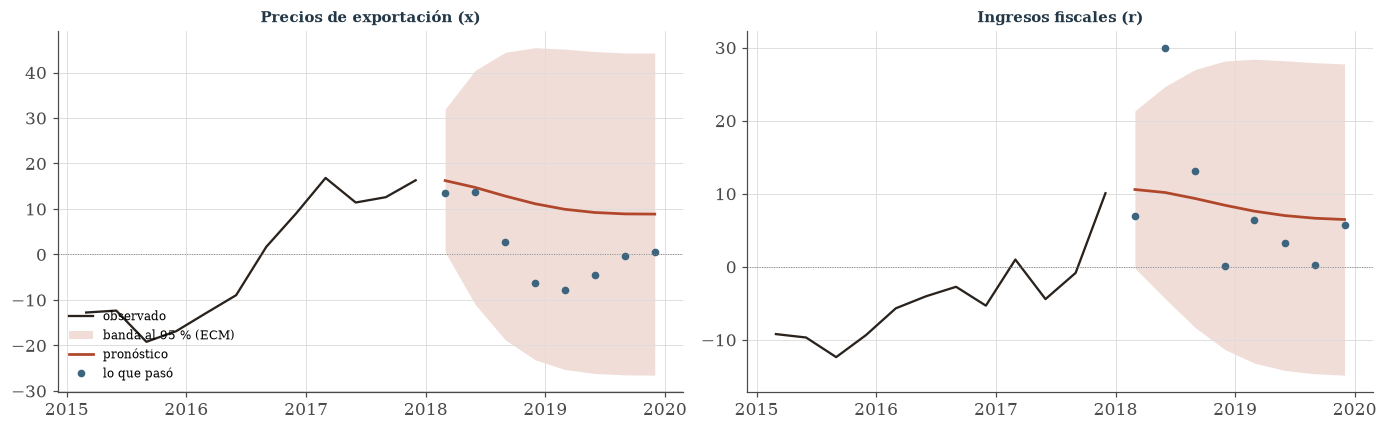

,ancho en h=1 (pp),ancho en h=8 (pp),dentro de la banda
x,31.4,70.8,8
r,21.6,42.6,7


In [5]:
h = 8
Sigma = U.T @ U / T                              # el de máxima verosimilitud
state = np.r_[y[-1], y[-2]]                      # ỹ_T = (y_T, y_{T-1})
mean, ecm = np.zeros((h, n)), np.zeros((h, n))
acc, F_j = np.zeros((n, n)), np.eye(n * p)
for j in range(h):
    state = c_tilde + F @ state                  # media: iterar sin choques
    mean[j] = J @ state
    Psi = J @ F_j @ J.T                          # Psi_j = J F^j J'
    acc = acc + Psi @ Sigma @ Psi.T              # Omega_{j+1} = Omega_j + Psi_j Sigma Psi_j'
    ecm[j] = np.diag(acc)                        # ECM_{i,h} = [Omega_h]_ii
    F_j = F_j @ F
lo, hi = mean - 1.96 * np.sqrt(ecm), mean + 1.96 * np.sqrt(ecm)

future = pd.date_range(data.index[-1] + pd.DateOffset(months=3), periods=h, freq="3MS")
actual = macrofiscal(levels).loc[future[0]:future[-1], ["x", "r"]]
titles = {"x": "Precios de exportación (x)", "r": "Ingresos fiscales (r)"}

fig, axes = plt.subplots(1, 2, figsize=(12.5, 3.8), constrained_layout=True)
for i, (ax, v) in enumerate(zip(axes, ["x", "r"])):
    hist = data[v].iloc[-12:]
    ax.plot(hist.index, hist, color="#2A231D", lw=1.5, label="observado")
    ax.fill_between(future, lo[:, i], hi[:, i], color="#B0472A", alpha=0.18, lw=0, label="banda al 95 % (ECM)")
    ax.plot(future, mean[:, i], color="#B0472A", lw=1.8, label="pronóstico")
    ax.plot(actual.index, actual[v], "o", color="#3D647F", ms=4, label="lo que pasó")
    ax.axhline(0, color="gray", lw=0.6, ls=":")
    ax.set_title(titles[v], fontsize=10)
axes[0].legend(fontsize=8, frameon=False, loc="lower left")
plt.show()

ancho = 2 * 1.96 * np.sqrt(ecm)
pd.DataFrame({"ancho en h=1 (pp)": ancho[0], "ancho en h=8 (pp)": ancho[-1],
              "dentro de la banda": [int(((actual[v] >= lo[:, i]) & (actual[v] <= hi[:, i])).sum())
                                     for i, v in enumerate(["x", "r"])]},
             index=["x", "r"]).round(1)

La banda se abre porque cada trimestre agrega un choque, y con un sistema estable se estabiliza
alrededor de la varianza incondicional. Pero hay algo que esta banda **no ve**: trata a $\hat B$ y
$\hat\Sigma$ como si fueran los verdaderos. La incertidumbre sobre los parámetros, que con diez
coeficientes y unas sesenta observaciones no es poca, queda fuera. La sesión 2 la incorpora: el
pronóstico bayesiano no suma un ECM, simula trayectorias con cada extracción de la posterior.

## Ejercicios

1. Reestime con $p = 1$ y con $p = 4$. ¿Cambia el máximo módulo de $F$? ¿Y el ancho de la banda a
   ocho trimestres?
2. Use $\hat\Sigma = \hat U'\hat U/(T-k)$ en lugar del de máxima verosimilitud. ¿Cuánto se ensancha
   la banda?
3. ¿Cuántos de los ocho trimestres de 2018-2019 caen dentro de la banda al 95 %? ¿Es lo que esperaría?
4. Pronostique 40 trimestres y verifique que la media converge a $\mu$ y que el ECM converge a la
   varianza incondicional.